Statistical analysis of the data collected in notebook 01. Eastbound first (more relevant).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
DATA = Path("../data")

eb_trains = pd.read_csv(DATA / "eb_trains.csv")
eb_trains["tfl_status"].unique()

array(['Good Service'], dtype=object)

In [2]:
eb_trains.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   station          1941 non-null   object
 1   train_no         1941 non-null   int64 
 2   destination      1941 non-null   object
 3   expected_arr     1941 non-null   object
 4   time_to_station  1941 non-null   int64 
 5   tfl_status       1941 non-null   object
 6   time             1941 non-null   object
dtypes: int64(2), object(5)
memory usage: 106.3+ KB


The TFL status is the same for all values, so it can be dropped.

In [3]:
eb_trains = eb_trains.drop("tfl_status", axis=1)
eb_trains.sort_values(["train_no", "station"]).head(5)

,station,train_no,destination,expected_arr,time_to_station,time
1614,EPY,45,Edgware Road,2026-07-21T15:55:30Z,453,2026-07-21 15:48:37.349300+00:00
1641,EPY,45,Edgware Road,2026-07-21T15:55:30Z,404,2026-07-21 15:49:25.898241+00:00
1656,EPY,45,Edgware Road,2026-07-21T15:56:32Z,442,2026-07-21 15:49:50.729961+00:00
1672,EPY,45,Edgware Road,2026-07-21T15:55:30Z,404,2026-07-21 15:50:14.483276+00:00
1687,EPY,45,Edgware Road,2026-07-21T15:56:01Z,366,2026-07-21 15:50:36.125801+00:00


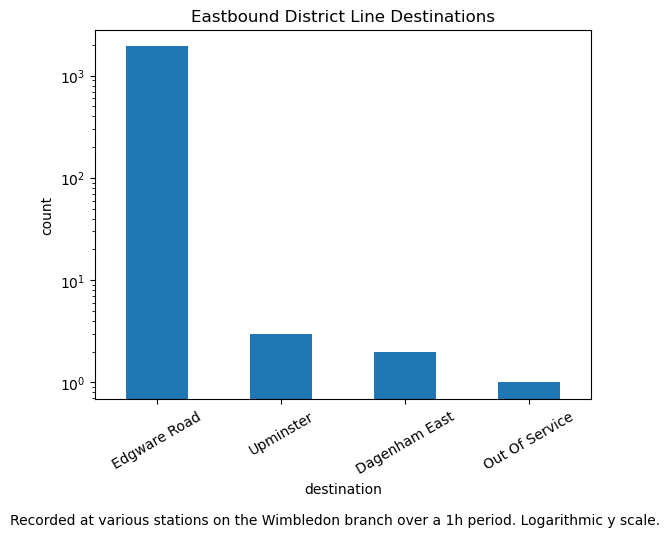

In [4]:
# distribution of train destinations
destinations = eb_trains["destination"].value_counts()

fig, ax = plt.subplots()
destinations.plot(kind="bar", ax=ax)
ax.set_yscale("log")
ax.set_ylabel("count")
ax.tick_params(axis="x", rotation=30)
ax.set_title("Eastbound District Line Destinations")
fig.text(
    0.5, -0.15,
    "Recorded at various stations on the Wimbledon branch over a 1h period. Logarithmic y scale.",
    ha="center",
    fontsize=10
)
#plt.savefig("destinations.png", bbox_inches="tight")
plt.show()

In [5]:
# create a column expected_arr - time
eb_trains["time"] = pd.to_datetime(eb_trains["time"], dayfirst=False)
eb_trains["wait_time"] = (pd.to_datetime(eb_trains["expected_arr"], format=f"%Y-%m-%dT%H:%M:%SZ", utc=True)- eb_trains['time']).dt.total_seconds()
eb_trains.head()

,station,train_no,destination,expected_arr,time_to_station,time,wait_time
0,PYB,52,Edgware Road,2026-07-21T14:51:05Z,65,2026-07-21 14:50:40.561666+00:00,24.438334
1,PSG,52,Edgware Road,2026-07-21T14:53:36Z,215,2026-07-21 14:50:40.969429+00:00,175.030571
2,FBY,52,Edgware Road,2026-07-21T14:55:35Z,333,2026-07-21 14:50:42.198421+00:00,292.801579
3,FBY,74,Edgware Road,2026-07-21T14:52:05Z,123,2026-07-21 14:50:42.202653+00:00,82.797347
4,PYB,52,Edgware Road,2026-07-21T14:51:05Z,65,2026-07-21 14:51:16.807428+00:00,-11.807428


Notice how the time_to_station and wait_time are quite different. This is probably due to TFL's load balancer. Let's see what the difference is.

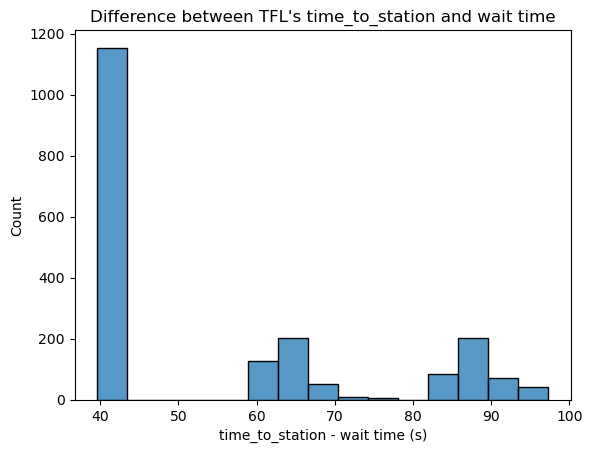

In [6]:
eb_trains["diff_tts_wt"] = eb_trains['time_to_station'] - eb_trains['wait_time']
fig, ax = plt.subplots()
sns.histplot(eb_trains["diff_tts_wt"], ax=ax)
ax.set_title("Difference between TFL's time_to_station and wait time")
ax.set_xlabel("time_to_station - wait time (s)")
plt.show()

There appears to be three main categories of differences. K-Means can be used to identify them.

In [7]:
# be careful of Windows memory leak with KMeans
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler

X = MinMaxScaler().fit_transform(eb_trains[["diff_tts_wt"]])
kmeans = KMeans(n_clusters=3, random_state=67, n_init="auto")
kmeans.fit(X)

c:\Users\ltang\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\ltang\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\ltang\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ltang\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

KMeans(n_clusters=3, random_state=67)

[[0.42776722]
 [0.01275764]
 [0.84541625]] 0.9345573834509066


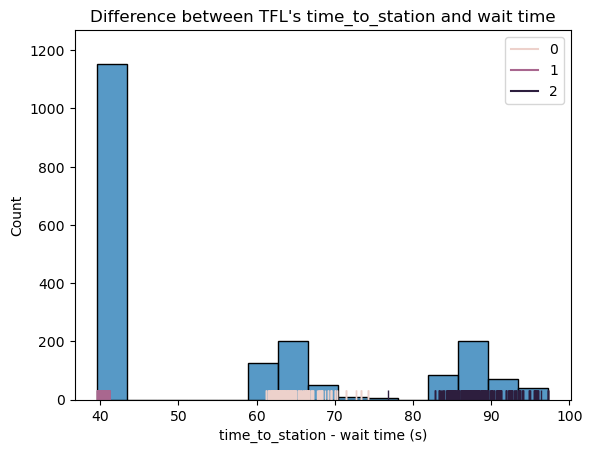

In [8]:
print(kmeans.cluster_centers_, silhouette_score(X, kmeans.labels_))

sns.histplot(eb_trains["diff_tts_wt"])
sns.rugplot(data=eb_trains, x="diff_tts_wt", hue=kmeans.labels_)
plt.title("Difference between TFL's time_to_station and wait time")
plt.xlabel("time_to_station - wait time (s)")
plt.show()

There seems to be discrete refresh rates with the API. This can be adjusted upon detecting a difference in times significantly over 40 seconds. 

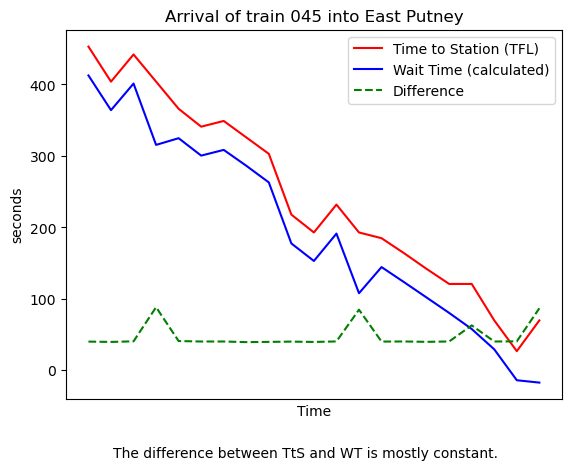

In [9]:
example_train_df = eb_trains[(eb_trains["train_no"]==45) & (eb_trains["station"]=="EPY")]

times = np.arange(0, len(example_train_df), 1) # can do because API was called at regular intervals
fig, ax = plt.subplots()
ax.plot(times, example_train_df["time_to_station"], c='red', label="Time to Station (TFL)")
ax.plot(times, example_train_df["wait_time"], c='blue', label="Wait Time (calculated)")
ax.plot(times, example_train_df["diff_tts_wt"], c='green', linestyle="--", label="Difference")
ax.set_xticks([])
ax.set_xlabel("Time")
ax.set_ylabel("seconds")
ax.legend()
ax.set_title("Arrival of train 045 into East Putney")
fig.text(
    0.5, -0.01,
    "The difference between TtS and WT is mostly constant.",
    ha="center",
    fontsize=10
)
plt.show()

The error seems to be from TFL's API, returning an older copy of the data. This affects time_to_station more than wait_time.

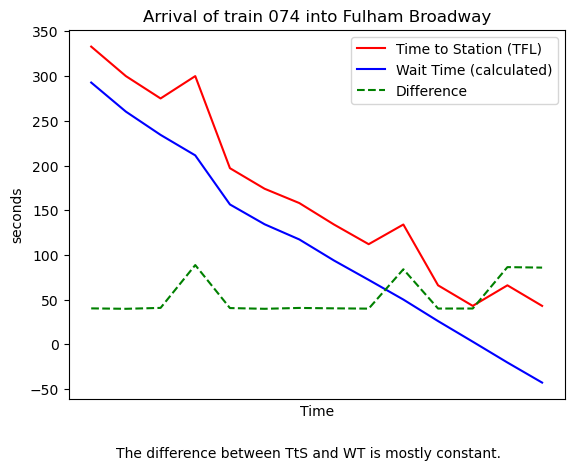

In [10]:
example_train_df = eb_trains[(eb_trains["train_no"]==52) & (eb_trains["station"]=="FBY")]

times = np.arange(0, len(example_train_df), 1) # can do because API was called at regular intervals
fig, ax = plt.subplots()
ax.plot(times, example_train_df["time_to_station"], c='red', label="Time to Station (TFL)")
ax.plot(times, example_train_df["wait_time"], c='blue', label="Wait Time (calculated)")
ax.plot(times, example_train_df["diff_tts_wt"], c='green', linestyle="--", label="Difference")
ax.set_xticks([])
ax.set_xlabel("Time")
ax.set_ylabel("seconds")
ax.legend()
ax.set_title("Arrival of train 074 into Fulham Broadway")
fig.text(
    0.5, -0.01,
    "The difference between TtS and WT is mostly constant.",
    ha="center",
    fontsize=10
)
plt.show()

The wait time looks mostly linear, which should indicate good service. 

Wait time:
- Less affected by TFL API issues 
- Can take negative values

Time to Station:
- Always positive time
- Can take the value of the API call two before current

Difference is around 40 seconds.

Questions/ideas:
- Negative wait time is probably just the train being at the station. Since the dwell time is roughly 20 seconds according to TFL, a wait time significantly lower than -20s can be marked as a delay.
- Can average adjusted time_to_station (average waiting time) at SFS be estimated?

Note that the adjustment is constant in the same API call, so average raw time_to_station is fine to use.

Some maths. $$E(Wait) = E(Wait|Train Showing) P(Train Showing) + E(Wait|Train Showing ^ c) P(Train Showing ^ c)$$ by the Law of Total Probability applied to expectations. So $E(Wait)$ can be inferred from the data.

In [11]:
sfs_eb_trains = eb_trains.copy()
sfs_eb_trains = sfs_eb_trains[sfs_eb_trains['station']=="SFS"]
sfs_eb_trains["time"] = sfs_eb_trains["time"].dt.strftime("%H:%M:%S")
sfs_eb_trains = sfs_eb_trains.sort_values("time").drop_duplicates("time", keep="first") # first train to arrive at SFS
sfs_eb_trains["adj_wait_time"] = (sfs_eb_trains["wait_time"]).round().clip(lower=0) # adjustment since negative wait time means train ready to board at station
# find times where the preceding API call(s) did not return anything
print(sfs_eb_trains[pd.to_datetime(sfs_eb_trains["time"], format="%H:%M:%S")-pd.to_datetime(sfs_eb_trains["time"], format="%H:%M:%S").shift(1) > pd.Timedelta(seconds=40)]["time"])

sfs_eb_trains.describe()

992     15:27:40
1715    15:51:52
Name: time, dtype: object


,train_no,time_to_station,wait_time,diff_tts_wt,adj_wait_time
count,163.000000,163.000000,163.000000,163.000000,163.000000
mean,64.226994,146.257669,88.927799,57.329870,94.521472
std,9.586063,79.174490,83.311457,20.178566,75.118206
min,45.000000,2.000000,-81.917301,39.731649,0.000000
25%,55.000000,79.000000,28.792178,40.373480,28.500000
50%,64.000000,146.000000,84.617938,40.880096,85.000000
75%,72.500000,209.500000,147.734257,76.828847,147.500000
max,77.000000,294.000000,253.318933,96.319616,253.000000


In [12]:
# find query times to compare missing times to. FBY had no missing queries due to being far enough from Wimbledon
fby_eb_trains = eb_trains.copy()
fby_eb_trains = fby_eb_trains[fby_eb_trains['station']=="FBY"]
fby_eb_trains["time"] = fby_eb_trains["time"].dt.strftime("%H:%M:%S")
fby_eb_trains = fby_eb_trains.sort_values("time").drop_duplicates("time", keep="first") # first train to arrive at SFS
fby_eb_trains["time"]

2       14:50:42
7       14:51:17
16      14:51:43
25      14:52:06
34      14:52:29
          ...   
1891    15:56:54
1904    15:57:17
1915    15:57:42
1925    15:58:07
1935    15:58:31
Name: time, Length: 169, dtype: object

The gap before 15:51:52 was caused by API lag rather than no train showing. There was missing data for three observations at the start, and four observations before 15:27:40, totalling $\frac{7}{169}$ occurrences of no train showing. The wait times were (288, 253, 227, 320, 296, 273, 251).

The average waiting time was 94.5 seconds with a train showing and 272.6 seconds with no train showing.

So $$E(Wait) = \frac{162}{169} \times 94.5 + \frac{7}{169} \times 272.6 = 101.9s.$$

Alternatively, a Monte Carlo simulation can be used. If the time is after the expected arrival, assume that the train is departing. Otherwise, add 20 seconds (dwell time) to the arrival time as an estimate of departure time.

In [13]:
# get the latest *DEPARTURE* estimates for trains
sfs_eb_trains = eb_trains.copy()
sfs_eb_trains = sfs_eb_trains[sfs_eb_trains['station']=="SFS"]
sfs_eb_trains["time"] = sfs_eb_trains["time"].dt.strftime("%H:%M:%S")
sfs_eb_trains["expected_dpt"] = (pd.to_datetime(sfs_eb_trains["expected_arr"], format=f"%Y-%m-%dT%H:%M:%SZ") + pd.Timedelta(seconds=20)).dt.strftime("%H:%M:%S")
sfs_eb_trains = sfs_eb_trains.sort_values("time").drop_duplicates("train_no", keep="last") # latest estimate for each train
sfs_eb_trains["dpt"] = sfs_eb_trains[["time", "expected_dpt"]].max(axis=1)
departures = sorted(list(sfs_eb_trains["dpt"]))

# Simulate 50,000 passengers arriving at a time in range [15:00:00, 16:00:00). Find their average waiting time.
from datetime import datetime
import random
reference = datetime.strptime("15:00:00", "%H:%M:%S")
seconds = [int((datetime.strptime(d, "%H:%M:%S") - reference).total_seconds()) for d in departures]
total_wait = 0
n_simulations = 50000
random.seed(42)
for pax in range(n_simulations):
    t = random.randint(0, 3599)
    i = np.searchsorted(seconds, t)
    wait_time = seconds[i] - t
    total_wait += max(wait_time-20, 0) # because no wait if train already at platform

total_wait/n_simulations

131.05764

The estimates for average waiting time are significantly different. The result derived from probability theory works in theory, but since some trains in the data are delayed at the station, there is a longer period of time where the waiting time is zero. This causes a lower average waiting time to board the train, even though time is spent waiting for the train to move. 

The Monte Carlo simulation is only subject to modelling assumptions, which should not have a large effect. The result of the Monte Carlo simulation will be used.

The hypothesis is that in real time, this can be estimated by the halved average headway at Fulham Broadway.

In [14]:
fby_eb_trains = eb_trains.copy()
fby_eb_trains = fby_eb_trains[fby_eb_trains['station']=="FBY"]
fby_eb_trains["time"] = fby_eb_trains["time"].dt.strftime("%H:%M:%S")
fby_eb_trains["adj_wait_time"] = (fby_eb_trains["wait_time"]).round().clip(lower=0) # adjustment since negative wait time means train ready to board at station

adj_wait_times = []
adj_headway = []
for _, search in fby_eb_trains.groupby("time"):
    if len(search) == 1:
        adj_headway.append(search["time_to_station"].iloc[0])
        adj_wait_times.append(search["adj_wait_time"].iloc[0])
    else:
        adj_headway.append((search["time_to_station"].max() - search["time_to_station"].min()) / (len(search)-1))
        adj_wait_times.append((search["adj_wait_time"].max() - search["adj_wait_time"].min()) / (len(search)-1))

f"Headway method: {sum(adj_headway)/(2*len(adj_headway))}, Wait Times method: {sum(adj_wait_times)/(2*len(adj_wait_times))}"

'Headway method: 135.10848126232742, Wait Times method: 134.2258382642998'

Both methods are accurate enough to estimate average wait time. The Headway method will be used in the app (despite a slightly larger error) since less calculations are required.

Disruption detection is simple. If the wait time is significantly below 0, the train is being held at a platform. TFL favour holding trains at stations rather than in between. If we query every station on this branch, we can see if trains are being held at platforms, and a delay can be predicted.

Tukey's criterion on adjusted wait time can also be used. Assuming this is normal operations, the IQR is 119 seconds. So if the adjusted wait time ever exceeds $Q_3 + 1.5 \times IQR = 326$ seconds on the line, delays because of train frequency can be predicted. This needs to be detected east of Southfields, as the maximum wait time is less than 326 seconds for a showing train.